# Exploratory Data Analysis

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import min, max
from pyspark.ml.feature import Imputer
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import Pipeline
from functools import reduce
import glob
import matplotlib.pyplot as plt
import pandas as pd

import os
job_scratch = os.environ["TMPDIR"]  # /scratch/lcheng7/job_46629476
spark_tmp = os.path.join(job_scratch, "spark_tmp")
os.makedirs(spark_tmp, exist_ok=True)

spark = (
    SparkSession.builder
    .config("spark.local.dir", spark_tmp)
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "18g")
    .config('spark.executor.instances', 7)
    .config("spark.sql.shuffle.partitions", "4000")
    .getOrCreate()
)

print("TMPDIR =", job_scratch)
print("spark.local.dir =", spark.sparkContext.getConf().get("spark.local.dir"))
print("parallelism =", spark.sparkContext.defaultParallelism)

ModuleNotFoundError: No module named 'pyspark'

In [4]:
!df -h /scratch/lcheng7/job_46629476
!du -sh /scratch/lcheng7/job_46629476 2>/dev/null

'df' is not recognized as an internal or external command,
operable program or batch file.
The system cannot find the path specified.


In [5]:
files = sorted(glob.glob("/home/lcheng7/dataset/fhvhv_tripdata_*.parquet"))
# columns that drift between int/string/double across months
CAST_TO_STRING = ["wav_match_flag"]
CAST_TO_DOUBLE = ["airport_fee"]

def load_one(path):
    d = spark.read.parquet(path)
    
    # cast wav_match_flag to string if present
    for c in CAST_TO_STRING:
        if c in d.columns:
            d = d.withColumn(c, F.col(c).cast("string"))
    
    # cast airport_fee to double if present
    for c in CAST_TO_DOUBLE:
        if c in d.columns:
            d = d.withColumn(c, F.col(c).cast("double"))
    
    return d

dfs = [load_one(p) for p in files]
df = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs)

NameError: name 'glob' is not defined

In [6]:
df.printSchema()

NameError: name 'df' is not defined

In [7]:
df.count()

NameError: name 'df' is not defined

In [8]:
df_small = df.limit(5).toPandas()
df_small

NameError: name 'df' is not defined

In [9]:
zones = spark.read.csv("dataset/taxi+_zone_lookup.csv", header=True, inferSchema=True)
zones_small = zones.limit(5).toPandas()
zones_small

NameError: name 'spark' is not defined

In [10]:
df.select(
    min("pickup_datetime").alias("min_pickup"),
    max("pickup_datetime").alias("max_pickup")
).show()

NameError: name 'df' is not defined

# Describe

In [11]:
desc = df.select(
    "trip_miles",
    "base_passenger_fare",
    "tolls",
    "congestion_surcharge",
    "airport_fee",
    "tips"
).describe()

desc_pd = desc.toPandas().set_index("summary")
desc_pd

NameError: name 'df' is not defined

## Unique Value Checks

In [12]:
categorical_cols = [
    "hvfhs_license_num",
    "shared_request_flag",
    "shared_match_flag",
    "access_a_ride_flag",
    "wav_request_flag",
    "wav_match_flag"
]

for col_name in categorical_cols:
    print(f"Distinct values for {col_name}:")
    df.groupBy(col_name).count().orderBy(F.desc("count")).show()

Distinct values for hvfhs_license_num:


NameError: name 'df' is not defined

## Duplicate Check

In [13]:
# Run once to save memory

dedupe_cols = [
    "hvfhs_license_num",
    "pickup_datetime",
    "dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_miles",
    "base_passenger_fare"
]

# output_path = "/home/lcheng7/cleaned_dataset/fhvhv_dedup"

# (df.dropDuplicates(dedupe_cols)
#    .write.mode("overwrite")
#    .parquet(output_path)
# )

In [14]:
df_clean = spark.read.parquet("/home/lcheng7/cleaned_dataset/fhvhv_dedup")
df = df_clean

NameError: name 'spark' is not defined

In [ ]:
# Trip duration in minutes
df = df.withColumn(
    "trip_duration_min",
    (F.col("dropoff_datetime").cast("long") -
     F.col("pickup_datetime").cast("long")) / 60
)

# Mean speed
df = df.withColumn(
    "avg_speed_mph",
    F.when(F.col("trip_duration_min") > 0,
           F.col("trip_miles") / F.col("trip_duration_min").cast("long")) / 60))
)

# Pickup hour and day of the week
df = df.withColumn("pickup_hour", F.hour("pickup_datetime"))
df = df.withColumn("pickup_dayofweek", F.dayofweek("pickup_datetime"))

df.select("trip_duration_min", "avg_speed_mph",
          "pickup_hour", "pickup_dayofweek").show(5)

In [ ]:
# Define feature groups

numeric_cols = [
    "trip_miles",
    "base_passenger_fare",
    "tolls",
    "congestion_surcharge",
    "airport_fee",
    "tips",
    "trip_duration_min",
    "avg_speed_mph"
]

categorical_cols = [
    "hvfhs_license_num",
    "shared_request_flag",
    "shared_match_flag",
    "access_a_ride_flag",
    "wav_request_flag",
    "wav_match_flag",
    "pickup_hour",
    "pickup_dayofweek"
]

In [ ]:
imputer = Imputer(
    inputCols=numeric_cols,
    outputCols=[c + "_imputed" for c in numeric_cols]
).setStrategy("median")

In [ ]:
# String Indexer
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_indexed", handleInvalid="keep")
    for c in categorical_cols
]

# One-Hot Encoder
encoder = OneHotEncoder(
    inputCols=[c + "_indexed" for c in categorical_cols],
    outputCols=[c + "_ohe" for c in categorical_cols]
)

In [ ]:
assembler = VectorAssembler(
    inputCols=[c + "_indexed" for c in categorical_cols] +
              [c + "_ohe" for c in categorical_cols],
    outputCols="features_unscaled"
)

In [ ]:
scaler = StandardScaler(
    inputCol="features_unscaled",
    outputCol="features",
    withMean=True,
    withStd=True
)

In [ ]:
pipeline = Pipeline(stages=
    [imputer] +
    indexers +
    [encoder, assembler, scaler]
)

pipeline_model = pipeline.fit(df)
df_preprocessed = pipeline_model.transform(df)
df_preprocessed.select("features").show(5, truncate=False)

In [13]:
df.count()

745273321

In [16]:
# Check if duplicates are gone
dup_probe = (
    df.groupBy(*dedupe_cols)
      .count()
      .filter(F.col("count") > 1)
      .limit(10)
)

dup_probe.show(truncate=False)

+-----------------+---------------+----------------+------------+------------+----------+-------------------+-----+
|hvfhs_license_num|pickup_datetime|dropoff_datetime|PULocationID|DOLocationID|trip_miles|base_passenger_fare|count|
+-----------------+---------------+----------------+------------+------------+----------+-------------------+-----+
+-----------------+---------------+----------------+------------+------------+----------+-------------------+-----+



## Missing Values Check

In [17]:
null_summary = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

null_summary.toPandas().T

,0
hvfhs_license_num,0
dispatching_base_num,2085
originating_base_num,204287545
request_datetime,108958
on_scene_datetime,207723525
pickup_datetime,0
dropoff_datetime,0
PULocationID,0
DOLocationID,0
trip_miles,0


# Part 3: Data Exploration using Spark

## (a)
There are a total of 745287023 obeservations before cleaning the dataset for duplicates or missing values.

## (b)
**Categorical Variables**

	•	hvfhs_license_num (string)
High-volume for-hire service provider license number.
Represents the service type (e.g., Uber, Lyft).

	•	shared_request_flag (string)
Indicates whether the ride was requested as shared.

	•	shared_match_flag (string)
Indicates whether the ride was matched as shared.

	•	access_a_ride_flag (string)
Accessibility ride indicator.

	•	wav_request_flag (string)
Wheelchair-accessible vehicle request flag.

	•	wav_match_flag (string)
Wheelchair-accessible vehicle match flag.

	•	PULocationID (long)
Pickup Taxi Zone ID (categorical geographic variable).

	•	DOLocationID (long)
Dropoff Taxi Zone ID.


**Continuous Variables**

	•	trip_miles (double)
Distance traveled in miles.

	•	trip_time (long)
Duration of trip in seconds.

	•	base_passenger_fare (double)
Core passenger fare before additional charges.

	•	tolls (double)
Tolls charged during the trip.

	•	bcf (double)
Black car fund surcharge.

	•	sales_tax (double)
Sales tax applied.

	•	congestion_surcharge (double)
Congestion pricing surcharge applied in specific zones.

	•	airport_fee (double)
Airport pickup surcharge.

	•	tips (double)
Tip amount paid by passenger.

	•	driver_pay (double)
Driver compensation.

## (c)

The primary research focus is tipping behavior. Two derived targets were analyzed:

	1.	Tipping Probability (Binary Target)
Whether tips > 0

	2.	Tip Magnitude (Continuous Target)
The numeric value of tips

This allows analysis of:

	•	Likelihood of tipping
	•	Amount tipped conditional on tipping

# Part 4: Plots

## Trip Volume Over Time

In [18]:
df_time = df.select(
    F.year("pickup_datetime").alias("year"),
    F.month("pickup_datetime").alias("month")
)

In [19]:
trips_per_year = (
    df_time
    .groupBy("year")
    .count()
    .orderBy("year")
)

trips_per_year_pd = trips_per_year.toPandas()
trips_per_year_pd

,year,count
0,2019,234625985
1,2020,143303198
2,2021,174595975
3,2022,192748163


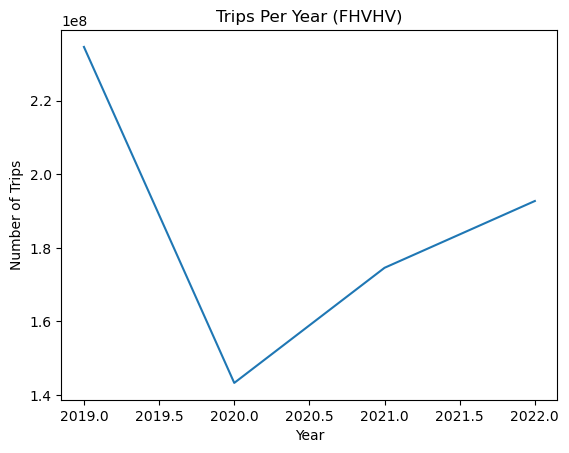

In [20]:
plt.figure()
plt.plot(trips_per_year_pd["year"], trips_per_year_pd["count"])
plt.xlabel("Year")
plt.ylabel("Number of Trips")
plt.title("Trips Per Year (FHVHV)")
plt.show()

Trip volume sharply declined during early pandemic months and has not yet exceeded pre-pandemic levels in the available dataset. This confirms macro-level demand shifts and establishes baseline trip activity patterns.

In [21]:
trips_per_month = (
    df
    .groupBy(
        F.year("pickup_datetime").alias("year"),
        F.month("pickup_datetime").alias("month")
    )
    .count()
    .orderBy("year", "month")
)

trips_per_month_pd = trips_per_month.toPandas()
trips_per_month_pd.head()

,year,month,count
0,2019,2,20158922
1,2019,3,23864505
2,2019,4,21733538
3,2019,5,22328392
4,2019,6,21000454


In [22]:
trips_per_month_pd["date"] = pd.to_datetime(
    trips_per_month_pd["year"].astype(str) + "-" +
    trips_per_month_pd["month"].astype(str) + "-01"
)

trips_per_month_pd = trips_per_month_pd.sort_values("date")

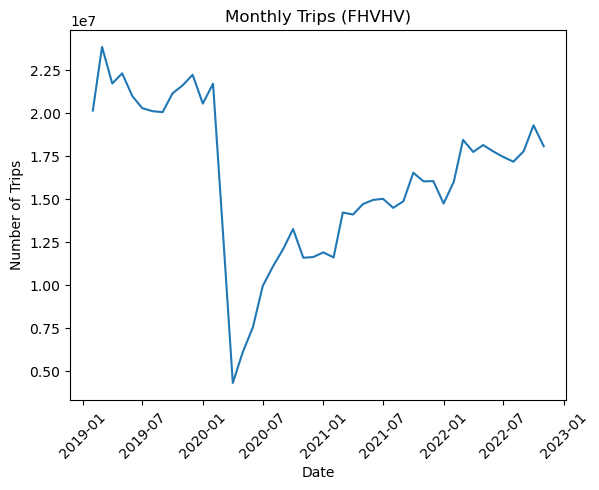

In [23]:
plt.figure()
plt.plot(trips_per_month_pd["date"], trips_per_month_pd["count"])
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.title("Monthly Trips (FHVHV)")
plt.xticks(rotation=45)
plt.show()

Further proves that trip volume sharply declined during early pandemic months and has not yet exceeded pre-pandemic levels in the available dataset.

## Fare Structure Breakdown

In [24]:
df_cost = df.withColumn(
    "total_cost",
    F.coalesce(F.col("base_passenger_fare"), F.lit(0)) +
    F.coalesce(F.col("tolls"), F.lit(0)) +
    F.coalesce(F.col("congestion_surcharge"), F.lit(0)) +
    F.coalesce(F.col("airport_fee"), F.lit(0)) +
    F.coalesce(F.col("tips"), F.lit(0))
)

In [25]:
df_sample = df_cost.sample(False, 0.002, seed=42)

cost_pd = (
    df_sample
    .select("total_cost")
    .toPandas()
)

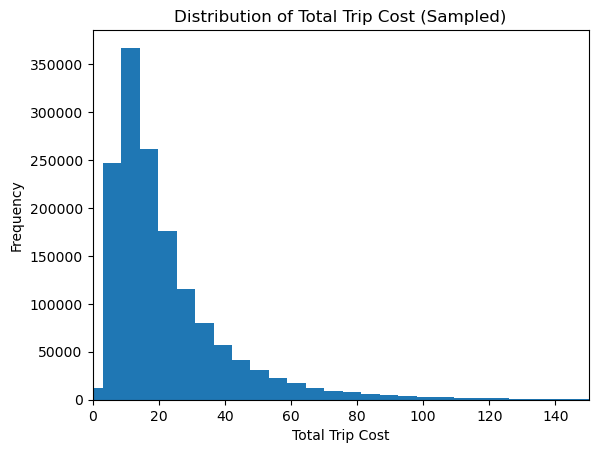

In [26]:
plt.figure()
plt.hist(cost_pd["total_cost"], bins=300)
plt.xlim(0, 150)
plt.xlabel("Total Trip Cost")
plt.ylabel("Frequency")
plt.title("Distribution of Total Trip Cost (Sampled)")
plt.show()

Fare distribution is heavily right-skewed, with the majority of trips clustered in lower fare ranges and a long tail of higher fares. This indicates that tip magnitude analysis must account for skewness and potential outliers.

### How Often Is Airport Fee Applied?

In [27]:
airport_stats = df_cost.select(
    F.mean(F.when(F.col("airport_fee") > 0, 1).otherwise(0)).alias("pct_airport_fee")
)

airport_stats.show()

+--------------------+
|     pct_airport_fee|
+--------------------+
|0.030255624835388413|
+--------------------+



### Congestion Surcharge Share of Cost

In [28]:
congestion_share = df_cost.select(
    F.mean(
        F.col("congestion_surcharge") / F.col("total_cost")
    ).alias("avg_congestion_share")
)

congestion_share.show()

+--------------------+
|avg_congestion_share|
+--------------------+
|1.0014251384192812E9|
+--------------------+



# Tipping Behavior

In [29]:
tip_stats = df_cost.select(
    F.mean(F.when(F.col("tips") > 0, 1).otherwise(0)).alias("pct_trips_with_tip"),
    F.mean("tips").alias("avg_tip_amount"),
    F.mean(F.col("tips") / F.col("base_passenger_fare")).alias("avg_tip_ratio")
)

tip_stats.show()

+-------------------+------------------+-------------------+
| pct_trips_with_tip|    avg_tip_amount|      avg_tip_ratio|
+-------------------+------------------+-------------------+
|0.15677103514617827|0.7621012075648183|0.03504062289533704|
+-------------------+------------------+-------------------+



In [40]:
df_tip = df.withColumn(
    "tip_binary",
    F.when(F.col("tips") > 0, 1).otherwise(0)
)

tip_counts = (
    df_tip.groupBy("tip_binary")
          .agg(F.count("*").alias("count"))
          .orderBy("tip_binary")
)

tip_pd = tip_counts.toPandas()
tip_pd

,tip_binary,count
0,0,628436051
1,1,116837270


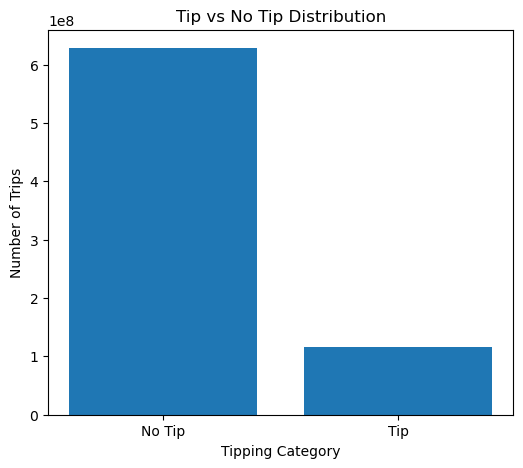

In [41]:
# Plot
plt.figure(figsize=(6,5))
plt.bar(tip_pd["tip_binary"], tip_pd["count"])
plt.xticks([0,1], ["No Tip", "Tip"])
plt.xlabel("Tipping Category")
plt.ylabel("Number of Trips")
plt.title("Tip vs No Tip Distribution")
plt.show()

In [30]:
df_tip_sample = df_cost.sample(False, 0.002, seed=42)

tip_pd = df_tip_sample.select("tips").toPandas()

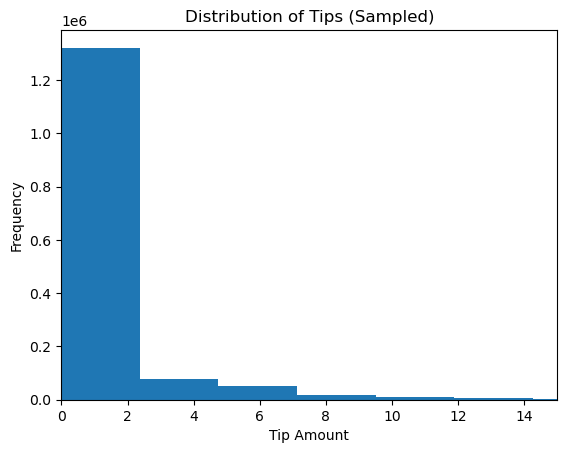

In [31]:
plt.figure()
plt.hist(tip_pd["tips"], bins=200)
plt.xlim(0, 15)
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Tips (Sampled)")
plt.show()

Tipping likelihood increases with fare size, suggesting that passengers are more likely to tip on higher-priced trips. This aligns with economic theory where tip amount often scales with total fare.

Also, average tip amount increases with fare, but not linearly. At very high fare levels, variability increases significantly, indicating heterogeneity in tipping behavior.

In [32]:
tips_by_hour = (
    df_cost
    .groupBy(F.hour("pickup_datetime").alias("hour"))
    .agg(
        F.mean(F.when(F.col("tips") > 0, 1).otherwise(0)).alias("tip_rate"),
        F.mean("tips").alias("avg_tip")
    )
    .orderBy("hour")
)

tips_by_hour_pd = tips_by_hour.toPandas()

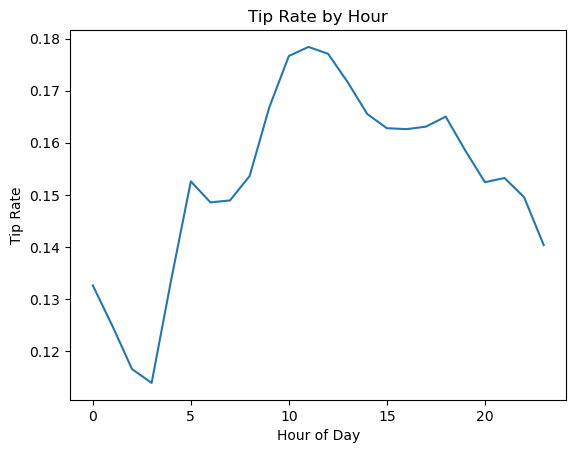

In [33]:
plt.figure()
plt.plot(tips_by_hour_pd["hour"], tips_by_hour_pd["tip_rate"])
plt.xlabel("Hour of Day")
plt.ylabel("Tip Rate")
plt.title("Tip Rate by Hour")
plt.show()

Tipping patterns vary by time of day. Peak evening hours tend to show higher average tip amounts, possibly due to longer trips or nightlife activity.

In [34]:
tips_by_distance = (
    df_cost
    .withColumn("distance_bucket", F.floor(F.col("trip_miles")))
    .groupBy("distance_bucket")
    .agg(
        F.mean("tips").alias("avg_tip"),
        F.mean(F.when(F.col("tips") > 0, 1).otherwise(0)).alias("tip_rate")
    )
    .orderBy("distance_bucket")
)

tips_by_distance_pd = tips_by_distance.toPandas()

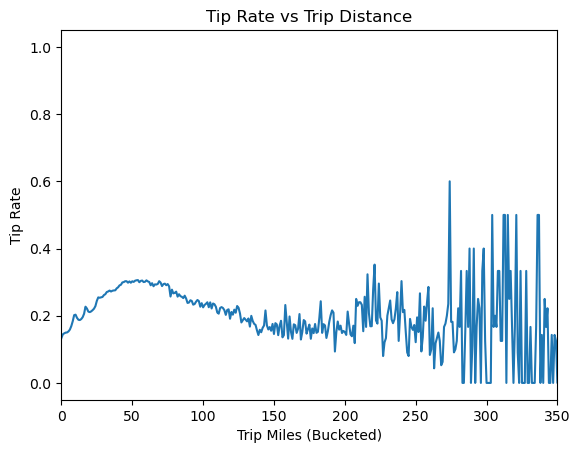

In [35]:
plt.figure()
plt.plot(
    tips_by_distance_pd["distance_bucket"],
    tips_by_distance_pd["tip_rate"]
)
plt.xlim(0, 350)
plt.xlabel("Trip Miles (Bucketed)")
plt.ylabel("Tip Rate")
plt.title("Tip Rate vs Trip Distance")
plt.show()

Significant geographic variation exists in tipping behavior. Some zones consistently exhibit higher tipping averages, potentially reflecting income distribution, airport effects, or business district influence.

## Does Airport incluence tipping?

In [36]:
df_airport = df_cost.withColumn(
    "is_airport",
    F.when(F.col("airport_fee") > 0, 1).otherwise(0)
)

In [37]:
airport_tip_stats = (
    df_airport
    .groupBy("is_airport")
    .agg(
        F.count("*").alias("n_trips"),
        F.mean(F.when(F.col("tips") > 0, 1).otherwise(0)).alias("tip_rate"),
        F.mean("tips").alias("avg_tip"),
        F.mean(F.col("tips") / F.col("base_passenger_fare")).alias("avg_tip_ratio"),
        F.mean("total_cost").alias("avg_total_cost")
    )
)

airport_tip_stats_pd = airport_tip_stats.toPandas()
airport_tip_stats_pd

,is_airport,n_trips,tip_rate,avg_tip,avg_tip_ratio,avg_total_cost
0,1,22548710,0.319365,3.205721,0.065988,60.184302
1,0,722724611,0.151698,0.685861,0.034071,21.640680


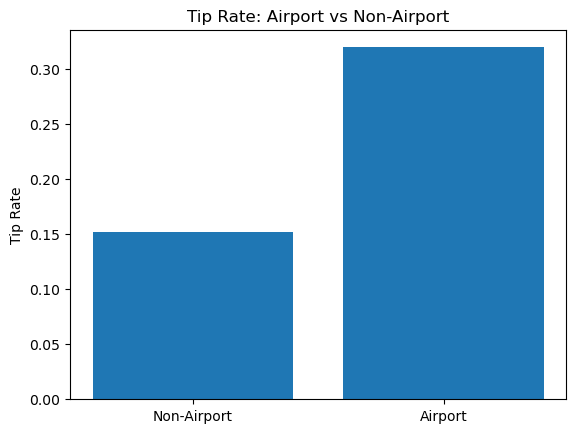

In [38]:
plt.figure()
plt.bar(
    ["Non-Airport", "Airport"],
    airport_tip_stats_pd.sort_values("is_airport")["tip_rate"]
)
plt.ylabel("Tip Rate")
plt.title("Tip Rate: Airport vs Non-Airport")
plt.show()

Trips subject to airport fees show different tipping patterns.

In [39]:
# # For crashes

# try:
#     spark.stop()
# except:
#     pass

# Part 5: Preprocessing Plan (3 points)

**How will you handle missing values?**

Missing values will be handled differently depending on variable type and analytical relevance.

dispatching_base_num (2,085 nulls): negligible relative to the full dataset size. (Replace null with "Unknown" to preserve trip records)

request_datetime (108,958 nulls): not required for tipping analysis (no imputation)

originating_base_num (~20M nulls): not required for tipping analysis (exclude from modeling)

on_scene_datetime (~20M nulls): not required for tipping analysis (exclude from modeling)

congestion_surcharge (513,041 nulls): Replace null with 0.0  (absence of congestion pricing is highly likely to imply that no surcharge applied.)

airport_fee (41,442,403 nulls): Replace null with 0.0  (airport_fee is only present for airport pickup, highly likely to imply that null means no airport charge)


**How will you handle data imbalance (if applicable)?**

To analyze tipping behavior, I created a binary variable where trips with tips > 0 are labeled as 1 and trips with no tip are labeled as 0.

The bar chart shows a clear imbalance in the dataset. Most trips do not include a tip. Only a smaller portion of trips have positive tips. This means the data is heavily skewed toward the “No Tip” class.

For descriptive analysis, I will not rebalance the dataset. The imbalance reflects real-world rider behavior, and changing it would distort the actual tipping patterns.

If I build a predictive model for tipping probability, I will handle imbalance using class-weighted methods instead of removing data. I will also use evaluation metrics like ROC-AUC, Precision-Recall, and F1-score instead of accuracy, since accuracy alone would be misleading in this case.

This imbalance is important because it affects how we interpret tipping behavior across fare size, time of day, pickup location, and policy-related surcharges.

**What transformations will you apply (scaling, encoding, feature engineering)?**

First, I will create a binary tipping variable where tips > 0 equals 1 and otherwise equals 0. This will allow me to analyze tipping probability.

Second, I will create a tip percentage variable by dividing tips by base_passenger_fare. This helps normalize tipping behavior relative to fare size.

From pickup_datetime, I will extract time-based features such as hour of day, day of week, and month. These features help analyze how tipping varies by time patterns.

I will also create a weekend indicator since rider behavior may differ on weekends.

For geographic analysis, I will treat PULocationID and DOLocationID as categorical variables. If I build a model, I will encode them using indexing rather than one-hot encoding because of high cardinality.

Continuous variables like trip miles, trip time, and fare amount may be standardized if I use linear models. However, if I use tree-based models, scaling will not be necessary.

Since fare and tip distributions are heavily right-skewed, I may apply a log transformation or cap extreme outliers to reduce the impact of unusually large trips.

All transformations will be done using Spark functions such as withColumn, VectorAssembler, and StringIndexer to ensure scalability.

**What Spark operations will you use for preprocessing?**

I will use Spark DataFrame operations so everything stays scalable.

I will use withColumn() to create new variables like tip_binary, tip_pct, hour of day, and day of week.

I will use fillna() to handle missing values in surcharge columns like airport_fee and congestion_surcharge by replacing null with 0.

I will use filter() to remove rows that are invalid or unusable, like missing timestamps if that ever happens.

I will use dropDuplicates() to remove duplicate trips based on a composite key and then save the cleaned dataset to Parquet.

I will use groupBy().agg() to compute aggregated features and summary statistics, like tipping rate by hour or by pickup zone.

I will use approxQuantile() to find extreme values and cap outliers for fare and trip distance if needed.

If I build a model, I will use Spark ML steps like StringIndexer for categorical encoding, VectorAssembler to build feature vectors, and StandardScaler only if scaling is needed.